In [19]:
import praw
import datetime
import time
import csv

# Configure your Reddit app credentials here.
reddit = praw.Reddit(
    client_id='DPN0VeSC6K0_0C4IFDXt2A',
    client_secret='g-JPmGQ9EGE7VdmziIrkavG3U2zVMQ',
    user_agent='project by u/the-sik'
)
print(f"Authenticated as: {reddit.user.me()}")

Authenticated as: None


In [8]:
subreddits = ['wallstreetbets', 'stocks', 'StockMarket', 'TSLA', 'RealTesla']
keywords = ['Tesla', 'TSLA', 'Elon Musk', 'Elon', '$TSLA', 'TeslaStock']

start_date = datetime.datetime(2023, 1, 1)
end_date = datetime.datetime(2023, 5, 31)
start_timestamp = int(start_date.timestamp())
end_timestamp = int(end_date.timestamp())

def search_submissions(subreddit_name, keyword):
    """
    Search for submissions in a given subreddit that match the keyword and fall within
    the specified UNIX timestamp range using cloudsearch syntax.
    """
    subreddit = reddit.subreddit(subreddit_name)
    # The query uses cloudsearch syntax to restrict by timestamp range along with the keyword.
    query = f'timestamp:{start_timestamp}..{end_timestamp} {keyword}'
    # Limit is set to 100; adjust if needed.
    return subreddit.search(query, syntax='cloudsearch', limit=100)

results = []

for subreddit_name in subreddits:
    for keyword in keywords:
        print(f"Searching in r/{subreddit_name} for posts with keyword '{keyword}'...")
        try:
            submissions = search_submissions(subreddit_name, keyword)
        except Exception as e:
            print(f"Error searching in r/{subreddit_name} with keyword '{keyword}': {e}")
            continue
        
        for submission in submissions:
            if submission.created_utc < start_timestamp or submission.created_utc > end_timestamp:
                continue

            print(f"Processing submission {submission.id}: {submission.title}")
            try:
                submission.comments.replace_more(limit=None)
            except Exception as e:
                print(f"Error expanding comments in submission {submission.id}: {e}")
                continue
            for comment in submission.comments.list():
                if not hasattr(comment, 'body'):
                    continue
                if keyword.lower() in comment.body.lower():
                    results.append({
                        'subreddit': subreddit_name,
                        'submission_id': submission.id,
                        'submission_title': submission.title,
                        'keyword': keyword,
                        'comment_id': comment.id,
                        'author': str(comment.author) if comment.author else 'N/A',
                        'body': comment.body,
                        'created_utc': comment.created_utc,
                    })
            time.sleep(1)

print(f"Extraction complete. Found {len(results)} comments matching the criteria.")

csv_filename = 'tesla_stock_discussions_2023.csv'
with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['subreddit', 'submission_id', 'submission_title', 'keyword', 'comment_id', 'author', 'body', 'created_utc']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for row in results:
        writer.writerow(row)

print(f"Data saved to {csv_filename}.")

Searching in r/wallstreetbets for posts with keyword 'Tesla'...
Searching in r/wallstreetbets for posts with keyword 'TSLA'...
Searching in r/wallstreetbets for posts with keyword 'Elon Musk'...
Processing submission 13i691q: Billionaire George Soros Cuts His Ties to Elon Musk. Sold All His Tesla Shares
Processing submission 13jpj0d: Elon Musk : " Offer me money. Offer me power. I don't care " 🔥
Processing submission 13ey9ub: Elon Musk says he's stepping down as Twitter CEO
Processing submission 13imguy: Elon Musk Subpoened in Jefferey Epstein case!
Searching in r/wallstreetbets for posts with keyword 'Elon'...
Searching in r/wallstreetbets for posts with keyword '$TSLA'...
Searching in r/wallstreetbets for posts with keyword 'TeslaStock'...
Searching in r/stocks for posts with keyword 'Tesla'...
Searching in r/stocks for posts with keyword 'TSLA'...
Searching in r/stocks for posts with keyword 'Elon Musk'...
Processing submission 1231cez: Elon Musk Says Twitter Worth $20 Billion, or L

In [12]:
keywords = ['TSLA']
start_date = datetime.datetime(2023, 1, 1)
end_date = datetime.datetime(2023, 5, 31)
start_timestamp = int(start_date.timestamp())
end_timestamp = int(end_date.timestamp())

def search_submissions(subreddit_name, keyword):
    subreddit = reddit.subreddit(subreddit_name)
    query = f'timestamp:{start_timestamp}..{end_timestamp} {keyword}'
    return subreddit.search(query, syntax='cloudsearch', limit=100)

results = []
for subreddit_name in subreddits:
    for keyword in keywords:
        print(f"Searching in r/{subreddit_name} for posts with keyword '{keyword}'...")
        try:
            submissions = search_submissions(subreddit_name, keyword)
        except Exception as e:
            print(f"Error searching in r/{subreddit_name} with keyword '{keyword}': {e}")
            continue
        
        for submission in submissions:
            # Verify that the submission falls within the desired date range.
            if submission.created_utc < start_timestamp or submission.created_utc > end_timestamp:
                continue

            print(f"Processing submission {submission.id}: {submission.title}")
            try:
                submission.comments.replace_more(limit=None)
            except Exception as e:
                print(f"Error expanding comments in submission {submission.id}: {e}")
                continue
            for comment in submission.comments.list():
                if not hasattr(comment, 'body'):
                    continue
                if keyword.lower() in comment.body.lower():
                    results.append({
                        'subreddit': subreddit_name,
                        'submission_id': submission.id,
                        'submission_title': submission.title,
                        'keyword': keyword,
                        'comment_id': comment.id,
                        'author': str(comment.author) if comment.author else 'N/A',
                        'body': comment.body,
                        'created_utc': comment.created_utc,
                    })
            time.sleep(1)

print(f"Extraction complete. Found {len(results)} comments matching the criteria.")

csv_filename = 'tesla_frstkeyword_2023.csv'
with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['subreddit', 'submission_id', 'submission_title', 'keyword', 'comment_id', 'author', 'body', 'created_utc']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for row in results:
        writer.writerow(row)

print(f"Data saved to {csv_filename}.")

Searching in r/wallstreetbets for posts with keyword 'TSLA'...
Searching in r/stocks for posts with keyword 'TSLA'...
Searching in r/StockMarket for posts with keyword 'TSLA'...
Searching in r/TSLA for posts with keyword 'TSLA'...
Searching in r/RealTesla for posts with keyword 'TSLA'...
Extraction complete. Found 0 comments matching the criteria.
Data saved to tesla_frstkeyword_2023.csv.


In [21]:
subreddits = ['wallstreetbets', 'stocks', 'StockMarket', 'TSLA', 'RealTesla']

def collect_comments(subreddit_name, start_date, end_date):
    subreddit = reddit.subreddit(subreddit_name)
    comments_data = []
    for submission in subreddit.top(limit=50):
        post_date = pd.to_datetime(submission.created_utc, unit='s')
        if start_date <= post_date <= end_date:
            for comment in submission.comments:
                if hasattr(comment, "body"):
                    comments_data.append([
                        submission.title,
                        submission.selftext,
                        post_date,
                        subreddit_name,
                        comment.body])
    
    return comments_data
    
comments_2023 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2023...")
    comments_2023.extend(collect_comments(subreddit, pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31")))
    time.sleep(1)

# For 2024 Reddit stock comments:
comments_2024 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2024...")
    comments_2024.extend(collect_comments(subreddit, pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")))
    time.sleep(1)

columns = ["Post Title", "Post Body", "Timestamp", "Subreddit", "Comment"]

comments_2023_df = pd.DataFrame(comments_2023, columns=columns)
comments_2024_df = pd.DataFrame(comments_2024, columns=columns)

comments_2023_df.to_csv('g2023.csv', index=False, encoding='utf-8')
comments_2024_df.to_csv('g2024.csv', index=False, encoding='utf-8')

print("Data extraction complete. 2023 and 2024 comments have been saved to CSV files.")

Data extraction complete. 2023 and 2024 comments have been saved to CSV files.


In [33]:
subreddits = ['wallstreetbets', 'stocks', 'StockMarket', 'TSLA', 'RealTesla']

def collect_comments(subreddit_name, start_date, end_date):
    subreddit = reddit.subreddit(subreddit_name)
    comments_data = []
    for submission in subreddit.top(limit=None):
        post_date = pd.to_datetime(submission.created_utc, unit='s')
        if start_date <= post_date <= end_date:
            for comment in submission.comments:
                if hasattr(comment, "body"):
                    comments_data.append([
                        submission.title,
                        submission.selftext,
                        post_date,
                        subreddit_name,
                        comment.body])
    
    return comments_data

comments_2023 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2023...")
    comments_2023.extend(collect_comments(subreddit, pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31")))
    time.sleep(1)

# For 2024 Reddit stock comments:
comments_2024 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2024...")
    comments_2024.extend(collect_comments(subreddit, pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")))
    time.sleep(1)

columns = ["Post Title", "Post Body", "Timestamp", "Subreddit", "Comment"]

comments_2023_df = pd.DataFrame(comments_2023, columns=columns)
comments_2024_df = pd.DataFrame(comments_2024, columns=columns)

comments_2023_df.to_csv('g2023_1.csv', index=False, encoding='utf-8')
comments_2024_df.to_csv('g2024_1.csv', index=False, encoding='utf-8')

print("Data extraction complete. 2023 and 2024 comments have been saved to CSV files.")

Data extraction complete. 2023 and 2024 comments have been saved to CSV files.


In [36]:
def collect_comments(subreddit_name, start_date, end_date):
    subreddit = reddit.subreddit(subreddit_name)
    comments_data = []
    for submission in subreddit.top(limit=None):
        post_date = pd.to_datetime(submission.created_utc, unit='s')
        if start_date <= post_date <= end_date:
            for comment in submission.comments:
                if hasattr(comment, "body"):
                    comments_data.append([
                        submission.title,
                        submission.selftext,
                        post_date,
                        subreddit_name,
                        comment.body])
    
    return comments_data

comments_2022 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2022...")
    comments_2022.extend(collect_comments(subreddit, pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31")))
    time.sleep(1)

comments_2025 = []
for subreddit in subreddits:
    print(f"Collecting comments from r/{subreddit} for 2025...")
    comments_2025.extend(collect_comments(subreddit, pd.Timestamp("2025-01-01"), pd.Timestamp("2025-03-31")))
    time.sleep(1)
    
comments_2022_df = pd.DataFrame(comments_2022, columns=columns)
comments_2025_df = pd.DataFrame(comments_2025, columns=columns)

comments_2022_df.to_csv('g2022.csv', index=False, encoding='utf-8')
comments_2025_df.to_csv('g2025.csv', index=False, encoding='utf-8')
print("Data extraction complete. 2022 and 2025 comments have been saved to CSV files.")

Data extraction complete. 2022 and 2025 comments have been saved to CSV files.


#2. Pre-processing:

In [38]:
import pandas as pd

# Load each year's dataset
df2022 = pd.read_csv('g2022.csv')
df2023 = pd.read_csv('g2023_1.csv')
df2024 = pd.read_csv('g2024_1.csv')
df2025 = pd.read_csv('g2025.csv')

# Concatenating:
df = pd.concat([df2022, df2023, df2024, df2025], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", list(df.columns))

Combined dataset shape: (208785, 5)
Columns: ['Post Title', 'Post Body', 'Timestamp', 'Subreddit', 'Comment']


In [40]:
print("Missing values before drop:")
print(df[['Post Title', 'Comment', 'Timestamp']].isnull().sum())

Missing values before drop:
Post Title    0
Comment       1
Timestamp     0
dtype: int64


In [42]:
df.dropna(subset=['Post Title', 'Comment', 'Timestamp'], inplace=True)
print("Dataset shape after dropping missing values:", df.shape)

Dataset shape after dropping missing values: (208784, 5)


We will now filter out entries that are not relevant for analysis. This includes comments that have been deleted or removed, bot-generated messages, and extremely short comments that likely carry little information.

In [44]:
import re
generic_words = ['yes', 'agree', 'thanks', 'thank you', 'ok', 'same', 'good', 'nice', 'cool', 'great']

def is_generic(comment):
    comment = comment.strip().lower()
    return comment in generic_words

def is_only_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  
                           "]+", flags=re.UNICODE)
    text_without_emojis = emoji_pattern.sub(r'', text)
    text_without_emojis = re.sub(r'\W+', '', text_without_emojis)
    return len(text_without_emojis) == 0

mask_generic = df['Comment'].apply(is_generic)
mask_emoji_only = df['Comment'].apply(is_only_emojis)

print("Entries with generic comments:", mask_generic.sum())
print("Entries with only emojis or symbols:", mask_emoji_only.sum())

df = df[~(mask_generic | mask_emoji_only)]
print("Dataset shape after removing generic and emoji-only comments:", df.shape)

Entries with generic comments: 463
Entries with only emojis or symbols: 813
Dataset shape after removing generic and emoji-only comments: (207508, 5)


Convert Timestamps to Datetime and Extract Date Components

In [46]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day

print(df[['Timestamp', 'Year', 'Month', 'Day']].head(3))

            Timestamp  Year  Month  Day
0 2022-11-11 02:19:27  2022     11   11
1 2022-11-11 02:19:27  2022     11   11
2 2022-11-11 02:19:27  2022     11   11


In [48]:
df['text_length_char'] = df['Comment'].str.len()
df['text_length_words'] = df['Comment'].str.split().str.len()

df['Post Body'] = df['Post Body'].fillna('')
df['Combined_Text'] = df['Post Title'] + ' ' + df['Post Body'] + ' ' + df['Comment']
df['Sentiment'] = None

print(df[['Post Title', 'Comment', 'text_length_words', 'Combined_Text', 'Sentiment']].head(2))

                 Post Title  \
0  What a dumpster fire LOL   
1  What a dumpster fire LOL   

                                             Comment  text_length_words  \
0  Posts about Twitter are not allowed and social...                 37   
1  The man said he would bring back comedy, didn'...                 15   

                                       Combined_Text Sentiment  
0  What a dumpster fire LOL  Posts about Twitter ...      None  
1  What a dumpster fire LOL  The man said he woul...      None  


In [50]:
df.to_csv('r2022to2025.csv', index=False)

Sentiment Analysis using RoBERTa
Pre-trained RoBERTa Sentiment Model (cardiffnlp/twitter-roberta-base-sentiment).

In [54]:
!pip install transformers
!pip install torch

import pandas as pd
from transformers import pipeline

df = pd.read_csv('r2022to2025.csv')

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use mps:0


In [4]:
import pandas as pd
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
from tqdm import tqdm

df = pd.read_csv('r2022to2025.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Combined_Text'] = df['Post Title'].astype(str) + " " + df['Comment'].astype(str)
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, truncation=True)

labels_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

def get_sentiment(text):
    try:
        if not text.strip(): 
            return 0
        output = sentiment_pipeline(text[:512])
        label_number = int(output[0]['label'].split('_')[-1])
        label = labels_map[label_number]
        score = output[0]['score']
        if label == 'Positive':
            return score
        elif label == 'Negative':
            return -score
        else:
            return 0
    except Exception as e:
        return 0

batch_size = 500
sentiment_scores = []

for start in tqdm(range(0, len(df), batch_size)):
    end = min(start + batch_size, len(df))
    batch_texts = df['Combined_Text'].iloc[start:end].astype(str).tolist()
    batch_results = [get_sentiment(text) for text in batch_texts]
    sentiment_scores.extend(batch_results)

    if start % (batch_size * 5) == 0:  # Every 2500 comments
        df_partial = df.iloc[:len(sentiment_scores)]
        df_partial['sentiment_score'] = sentiment_scores
        df_partial.to_csv('reddit_comments_partial_sentiment.csv', index=False)

df['sentiment_score'] = sentiment_scores
df.to_csv('reddit_comments_with_sentiment.csv', index=False)

print("Sentiment analysis DONE and saved as 'reddit_comments_with_sentiment.csv'!")

Device set to use mps:0
  0%|                                                   | 0/416 [00:00<?, ?it/s]Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
/var/folders/f7/cdjw2tpj2vq4886wsx_dszjm0000gn/T/ipykernel_33023/1690964192.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_partial['sentiment_score'] = sentiment_scores
  1%|▌                                          | 5/416 [00:38<51:12,  7.48s/it]/var/folders/f7/cdjw2tpj2vq4886wsx_dszjm0000gn/T/ipykernel_33023/1690964192.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

🎯 Sentiment analysis DONE and saved as 'reddit_comments_with_sentiment.csv'!


#Checking for emojis and empty comments for better processing.

In [4]:
import pandas as pd
df = pd.read_csv('reddit_comments_with_sentiment.csv')
print(f"Original dataset size: {df.shape}")

emoji_pattern = r'^[^\w\s,.!?]*$'
mask_emoji_only = df['Comment'].astype(str).str.match(emoji_pattern)

print(f"Emoji-only comments to remove: {mask_emoji_only.sum()}")
df = df[~mask_emoji_only]

mask_empty_text = df['Combined_Text'].astype(str).str.strip() == ""
print(f"Empty Combined_Text rows to remove: {mask_empty_text.sum()}")
df = df[~mask_empty_text]

mask_empty_comment = df['Comment'].astype(str).str.strip() == ""
print(f"Empty Comment rows to remove: {mask_empty_comment.sum()}")
df = df[~mask_empty_comment]

print(f"Dataset size after cleaning: {df.shape}")
df.to_csv('redditcleanedfile1.csv', index=False)

print("Cleaning complete! File saved as 'reddit_comments_with_sentiment_cleaned.csv'.")

Original dataset size: (207508, 13)
Emoji-only comments to remove: 0
Empty Combined_Text rows to remove: 0
Empty Comment rows to remove: 0
Dataset size after cleaning: (207508, 13)
Cleaning complete! File saved as 'reddit_comments_with_sentiment_cleaned.csv'.


In [8]:
df = pd.read_csv('redditcleanedfile1.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Year'] = df['Timestamp'].dt.year
yearly_sentiment = df.groupby('Year')['sentiment_score'].mean().reset_index()
yearly_sentiment.columns = ['Year', 'Average_Sentiment']

print(yearly_sentiment)

   Year  Average_Sentiment
0  2022          -0.205957
1  2023          -0.240472
2  2024          -0.311535
3  2025          -0.367256


In [20]:
import pandas as pd

df = pd.read_csv('redditcleanedfile1.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month

monthly_sentiment = df.groupby(['Year', 'Month'])['sentiment_score'].mean().reset_index()
monthly_sentiment.to_csv('monthly_avg_sentiment.csv', index=False)

print(monthly_sentiment)

    Year  Month  sentiment_score
0   2022      1        -0.126230
1   2022      2        -0.206357
2   2022      3        -0.293833
3   2022      4        -0.160336
4   2022      5        -0.181165
5   2022      6        -0.214043
6   2022      7        -0.282087
7   2022      8        -0.079789
8   2022      9        -0.266183
9   2022     10        -0.173608
10  2022     11        -0.306174
11  2022     12        -0.266535
12  2023      1        -0.169452
13  2023      2        -0.203096
14  2023      3        -0.254253
15  2023      4        -0.158251
16  2023      5        -0.145428
17  2023      6        -0.019479
18  2023      7        -0.303514
19  2023      8        -0.381280
20  2023      9        -0.387412
21  2023     10        -0.269992
22  2023     11        -0.213440
23  2023     12        -0.346999
24  2024      1        -0.328932
25  2024      2        -0.254630
26  2024      3        -0.327204
27  2024      4        -0.346666
28  2024      5        -0.319989
29  2024  

In [149]:
monthly_sentiment.to_csv('monthly_avg_sentiment.csv', index=False)

In [153]:
df = pd.read_csv('monthly_avg_sentiment.csv')  # columns: Year, Month, sentiment_score

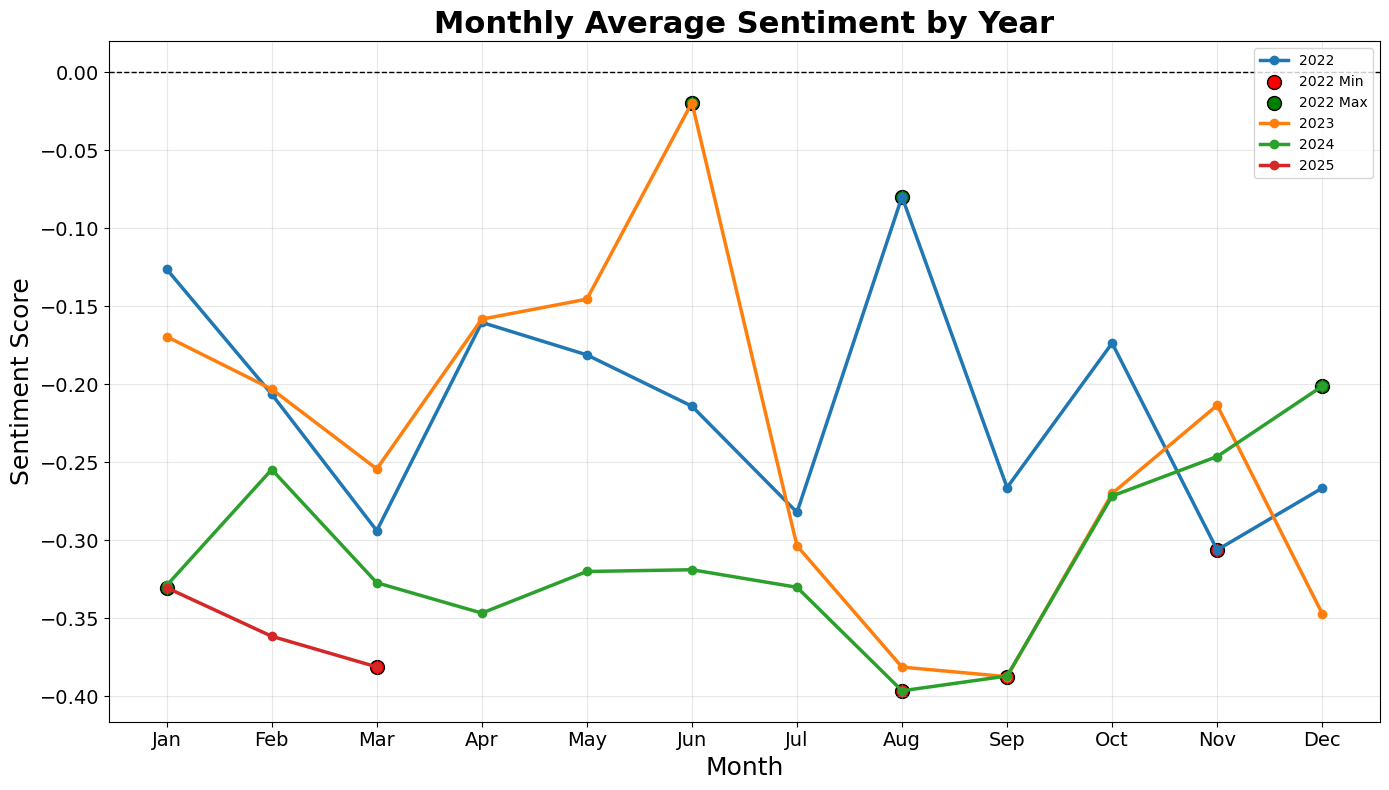

In [177]:
import pandas as pd
import matplotlib.pyplot as plt

df['Month'] = df['Month'].astype(int)
pivot_df = df.pivot(index='Month', columns='Year', values='sentiment_score')
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.get_cmap('tab10')  # Better colors
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, year in enumerate(pivot_df.columns):
    ax.plot(months[:len(pivot_df[year])], pivot_df[year], 
            label=str(year), 
            marker='o', 
            linewidth=2.5,
            color=colors(i))
    
    min_idx = pivot_df[year].idxmin()
    max_idx = pivot_df[year].idxmax()
    
    ax.scatter(months[min_idx-1], pivot_df.loc[min_idx, year], 
               color='red', s=100, edgecolor='black', label=f"{year} Min" if i==0 else None)
    ax.scatter(months[max_idx-1], pivot_df.loc[max_idx, year], 
               color='green', s=100, edgecolor='black', label=f"{year} Max" if i==0 else None)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Monthly Average Sentiment by Year', fontsize=22, fontweight='bold')
plt.xlabel('Month', fontsize=18)
plt.ylabel('Sentiment Score', fontsize=18)
plt.grid(alpha=0.3)
plt.legend(fontsize=10, loc='upper right', frameon=True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
import yfinance as yf
tsla = yf.download('TSLA', start='2022-01-01', end='2025-04-01')

print(tsla.head(10))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2022-01-03  399.926666  400.356659  378.679993  382.583344  103931400
2022-01-04  383.196655  402.666656  374.350006  396.516663  100248300
2022-01-05  362.706665  390.113342  360.336670  382.216675   80119800
2022-01-06  354.899994  362.666656  340.166656  359.000000   90336600
2022-01-07  342.320007  360.309998  336.666656  360.123322   84164700
2022-01-10  352.706665  353.033325  326.666656  333.333344   91815000
2022-01-11  354.799988  358.616669  346.273346  351.223328   66063300
2022-01-12  368.739990  371.613342  357.529999  359.616669   83739000
2022-01-13  343.853333  371.866669  342.179993  369.690002   97209900
2022-01-14  349.869995  350.666656  337.793335  339.959991   72924300


In [18]:
tsla['Year'] = tsla.index.year
yearly_stock = tsla.groupby('Year')['Close'].mean().reset_index()
yearly_stock.columns = ['Year', 'Average_Stock_Price']

print(yearly_stock)

   Year  Average_Stock_Price
0  2022           263.093081
1  2023           217.475240
2  2024           230.614961
3  2025           333.263333


In [10]:
import pandas as pd
import yfinance as yf

tsla = yf.download('TSLA', start='2022-01-01', end='2025-04-01')
tsla['Year'] = tsla.index.year
tsla['Month'] = tsla.index.month

monthly_stock = tsla.groupby(['Year', 'Month'])['Close'].mean().reset_index()
monthly_stock.rename(columns={'Close': 'Average_Stock_Price'}, inplace=True)
monthly_stock['Month_Name'] = monthly_stock['Month'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%b'))
monthly_stock = monthly_stock[['Year', 'Month', 'Month_Name', 'Average_Stock_Price']]
monthly_stock['Average_Stock_Price'] = monthly_stock['Average_Stock_Price'].round(2)

print(monthly_stock.to_string(index=False))

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Year Month Month_Name Average_Stock_Price
                                     TSLA
2022     1        Jan              336.72
2022     2        Feb              292.96
2022     3        Mar              304.79
2022     4        Apr              332.46
2022     5        May              255.22
2022     6        Jun              234.03
2022     7        Jul              251.39
2022     8        Aug              294.87
2022     9        Sep              288.73
2022    10        Oct              223.81
2022    11        Nov              191.25
2022    12        Dec              152.97
2023     1        Jan              134.20
2023     2        Feb              199.78
2023     3        Mar              188.52
2023     4        Apr              176.96
2023     5        May              175.80
2023     6        Jun              246.09
2023     7        Jul              273.51
2023     8        Aug              242.33
2023     9        Sep              256.97
2023    10        Oct             

In [12]:
monthly_stock['Average_Stock_Price'] = monthly_stock['Average_Stock_Price'].squeeze()
if len(monthly_stock['Average_Stock_Price'].shape) > 1 and monthly_stock['Average_Stock_Price'].shape[1] == 1:
    monthly_stock['Average_Stock_Price'] = monthly_stock['Average_Stock_Price'].squeeze()

/var/folders/f7/cdjw2tpj2vq4886wsx_dszjm0000gn/T/ipykernel_32112/3556661221.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


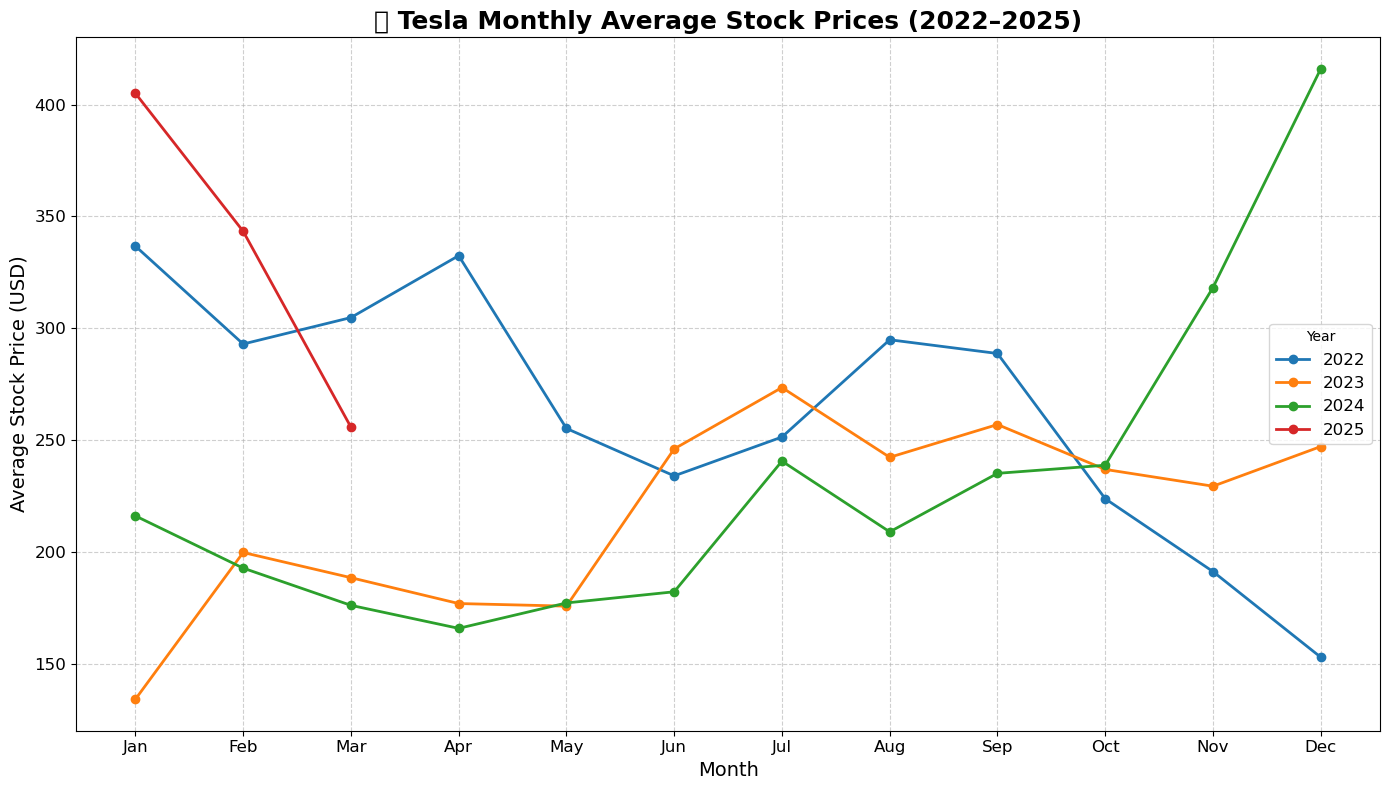

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
years = monthly_stock['Year'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

for i, year in enumerate(years):
    subset = monthly_stock[monthly_stock['Year'] == year]
    plt.plot(subset['Month'], subset['Average_Stock_Price'], 
             label=str(year), 
             color=colors[i], 
             marker='o', 
             linewidth=2)

plt.title('📈 Tesla Monthly Average Stock Prices (2022–2025)', fontsize=18, weight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Stock Price (USD)', fontsize=14)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [22]:
print(monthly_stock.index)
print(monthly_sentiment.index)

RangeIndex(start=0, stop=39, step=1)
RangeIndex(start=0, stop=39, step=1)


In [24]:
print(monthly_stock.columns)
print(monthly_sentiment.columns)

MultiIndex([(               'Year',     ''),
            (              'Month',     ''),
            (         'Month_Name',     ''),
            ('Average_Stock_Price', 'TSLA')],
           names=['Price', 'Ticker'])
Index(['Year', 'Month', 'sentiment_score'], dtype='object')


In [26]:
monthly_stock.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in monthly_stock.columns]
monthly_stock.columns = [col.rstrip('_') for col in monthly_stock.columns]

In [28]:
print(monthly_stock.columns)

Index(['Year', 'Month', 'Month_Name', 'Average_Stock_Price_TSLA'], dtype='object')


In [30]:
merged_data = pd.merge(monthly_stock, monthly_sentiment, on=['Year', 'Month'])

In [37]:
import calendar
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

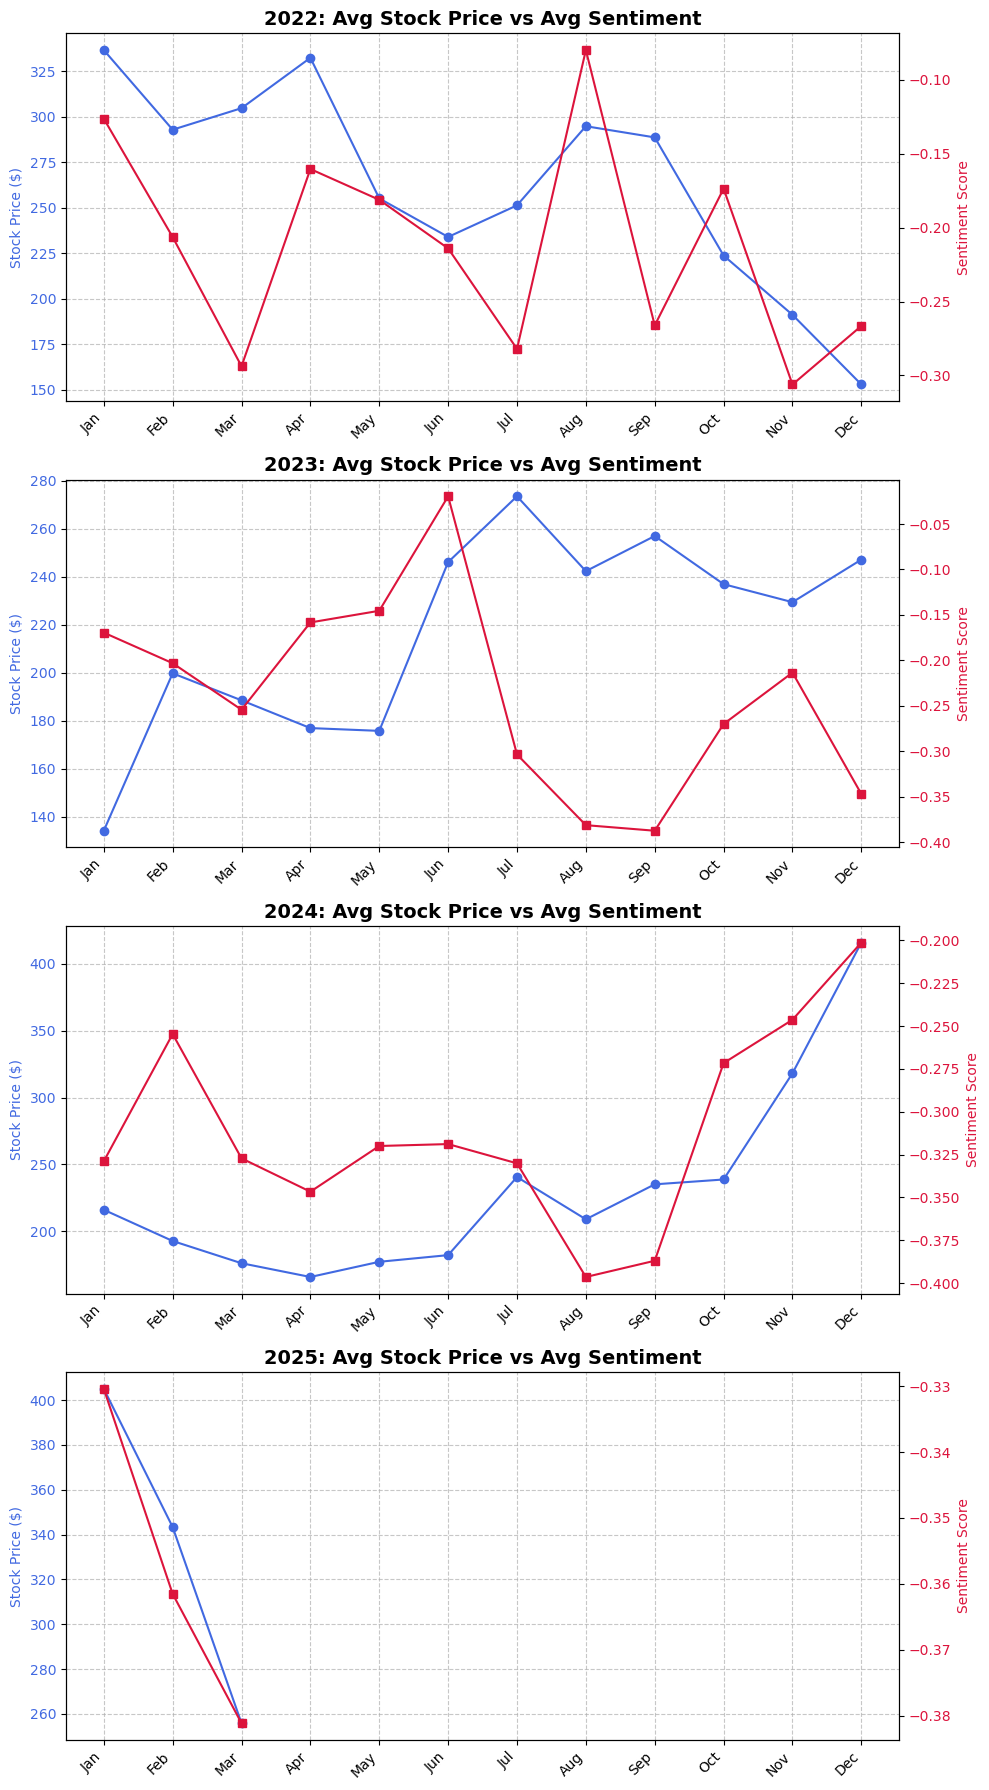

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

monthly_stock.columns = [col.rstrip('_') for col in monthly_stock.columns]  # Clean underscores
merged_data = pd.merge(monthly_stock, monthly_sentiment, on=['Year', 'Month'])

plt.style.use('seaborn-v0_8-muted')  # Elegant theme
years = sorted(merged_data['Year'].unique())

fig, axes = plt.subplots(len(years), 1, figsize=(10, 18), sharex=True)

for idx, year in enumerate(years):
    year_data = merged_data[merged_data['Year'] == year]
    
    ax = axes[idx]
    ax.plot(year_data['Month'], year_data['Average_Stock_Price_TSLA'], marker='o', color='royalblue', label='Avg Stock Price')
    ax.set_ylabel('Stock Price ($)', color='royalblue')
    ax.tick_params(axis='y', labelcolor='royalblue')
    ax.set_xticks(range(1, 13))
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, rotation=45, ha='right')
    ax.tick_params(axis='x', labelbottom=True)

    ax2 = ax.twinx()
    ax2.plot(year_data['Month'], year_data['sentiment_score'], marker='s', color='crimson', label='Avg Sentiment Score')
    ax2.set_ylabel('Sentiment Score', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    ax.set_title(f"{year}: Avg Stock Price vs Avg Sentiment", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.xlabel('Month')
plt.tight_layout()
plt.show()

   Year  Average_Sentiment  Average_Stock_Price
0  2022          -0.205957           263.093081
1  2023          -0.240472           217.475240
2  2024          -0.311535           230.614961
3  2025          -0.367256           333.263333


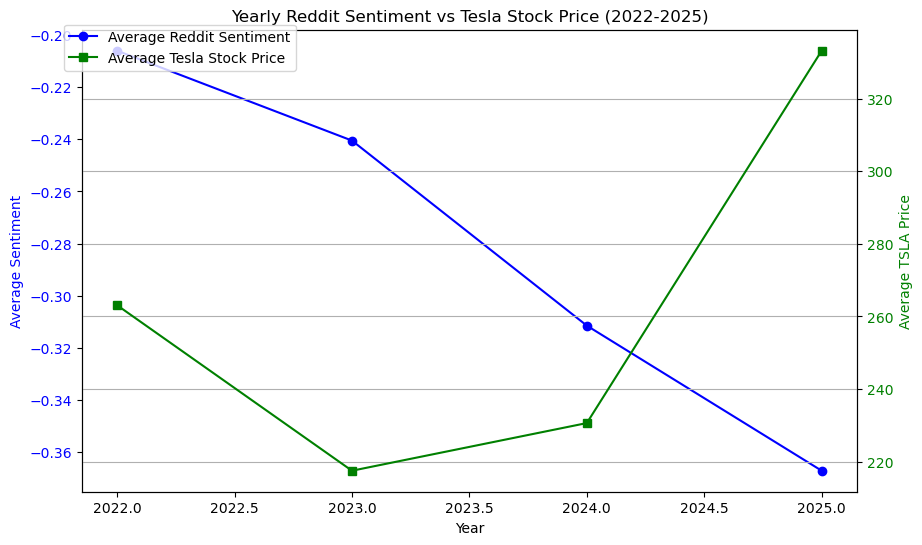

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

merged_df = pd.merge(yearly_sentiment, yearly_stock, on='Year')

print(merged_df)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(merged_df['Year'], merged_df['Average_Sentiment'], color='blue', marker='o', label='Average Reddit Sentiment')
ax1.set_ylabel('Average Sentiment', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(merged_df['Year'], merged_df['Average_Stock_Price'], color='green', marker='s', label='Average Tesla Stock Price')
ax2.set_ylabel('Average TSLA Price', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Yearly Reddit Sentiment vs Tesla Stock Price (2022-2025)')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.grid()

plt.show()

In [2]:
import yfinance as yf
import pandas as pd

tsla = yf.download('TSLA', start='2022-01-01', end='2025-04-01')
important_dates = [
    '2022-04-21', '2022-03-16',
    '2023-01-03', '2023-09-13', '2023-04-20',
    '2024-06-07', '2024-12-11',
    '2025-02-14', '2025-03-05']

tsla.index = pd.to_datetime(tsla.index)
selected_prices = tsla.loc[important_dates]
print(selected_prices[['Close']])

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            TSLA
Date                  
2022-04-21  336.260010
2022-03-16  280.076660
2023-01-03  108.099998
2023-09-13  271.299988
2023-04-20  162.990005
2024-06-07  177.479996
2024-12-11  424.769989
2025-02-14  355.839996
2025-03-05  279.100006


In [74]:
import pandas as pd
d = pd.read_csv('reddit_comments_with_sentiment.csv')

In [76]:
d.head()

,Post Title,Post Body,Timestamp,Subreddit,Comment,Year,Month,Day,text_length_char,text_length_words,Combined_Text,Sentiment,sentiment_score
0,What a dumpster fire LOL,NaN,2022-11-11 02:19:27,wallstreetbets,Posts about Twitter are not allowed and social...,2022,11,11,217,37,What a dumpster fire LOL Posts about Twitter a...,NaN,-0.639404
1,What a dumpster fire LOL,NaN,2022-11-11 02:19:27,wallstreetbets,"The man said he would bring back comedy, didn'...",2022,11,11,79,15,What a dumpster fire LOL The man said he would...,NaN,-0.661962
2,What a dumpster fire LOL,NaN,2022-11-11 02:19:27,wallstreetbets,Investigate 311,2022,11,11,15,2,What a dumpster fire LOL Investigate 311,NaN,-0.881334
3,What a dumpster fire LOL,NaN,2022-11-11 02:19:27,wallstreetbets,Y’all remember when we used to need to photosh...,2022,11,11,101,18,What a dumpster fire LOL Y’all remember when w...,NaN,-0.511418
4,What a dumpster fire LOL,NaN,2022-11-11 02:19:27,wallstreetbets,Anyone else find it a bit sus that they found ...,2022,11,11,93,19,What a dumpster fire LOL Anyone else find it a...,NaN,-0.856446


In [78]:
d['Timestamp'] = pd.to_datetime(d['Timestamp'])
d['Year'] = d['Timestamp'].dt.year
d['Month'] = d['Timestamp'].dt.month
d['Day'] = d['Timestamp'].dt.day

# 2022

In [84]:
import pandas as pd
from top2vec import Top2Vec

d = pd.read_csv('reddit_comments_with_sentiment.csv')
d['Timestamp'] = pd.to_datetime(d['Timestamp'])

In [323]:
#2022-04-21
data_2022_04_21 = d[
    (d['Year'] == 2022) & 
    (d['Month'] == 4) & 
    (d['Day'] == 21)]

texts_2022_04_21 = data_2022_04_21['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2022-04-21: {len(texts_2022_04_21)}")

model_2022_04_21 = Top2Vec(
    texts_2022_04_21,
    embedding_model='all-MiniLM-L6-v2', 
    speed='learn',
    workers=4)

topic_words_2022_04_21, _, _ = model_2022_04_21.get_topics()
for i, words in enumerate(topic_words_2022_04_21):
    print(f"Topic {i}: {words}")

2025-04-14 01:52:57,039 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 01:52:57,058 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2022-04-21: 133


2025-04-14 01:52:58,106 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 01:52:59,063 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 01:52:59,124 - top2vec - INFO - Finding dense areas of documents
2025-04-14 01:52:59,126 - top2vec - INFO - Finding topics


Topic 0: ['florida' 'disney' 'bill' 'governing' 'house' 'passes' 'status' 'over'
 'netflix' 'self' 'investors' 'percent' 'special' 'the' 'dissolve' 'urged'
 'to' 'is' 'and' 'down' 'jim' 'since' 'now' 'buy' 'stock' 'date' 'cramer']
Topic 1: ['netflix' 'investors' 'stock' 'cramer' 'percent' 'down' 'buy' 'jim'
 'urged' 'status' 'disney' 'now' 'since' 'over' 'special' 'date' 'house'
 'florida' 'and' 'is' 'to' 'self' 'dissolve' 'bill' 'the' 'governing'
 'passes']


[*********************100%***********************]  1 of 1 completed


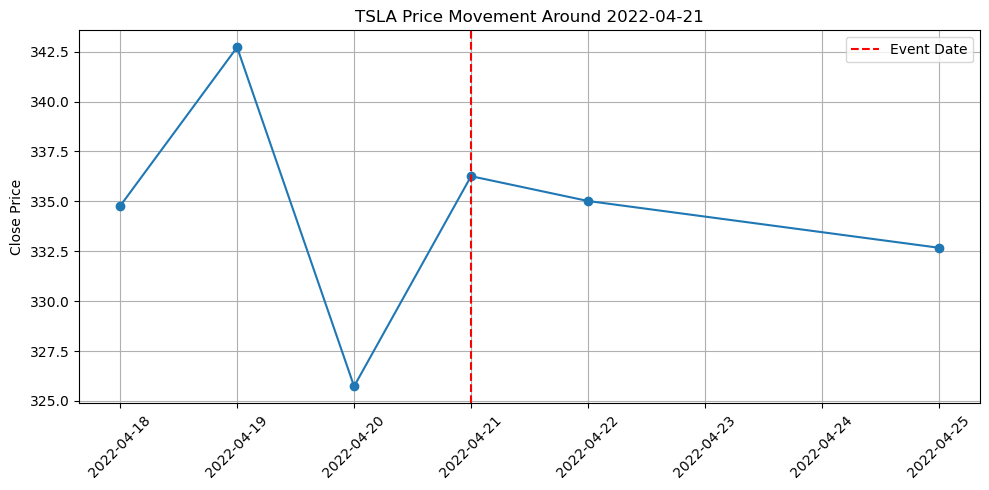

In [4]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

event_date = pd.to_datetime("2022-04-21")
ticker = "TSLA"
tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


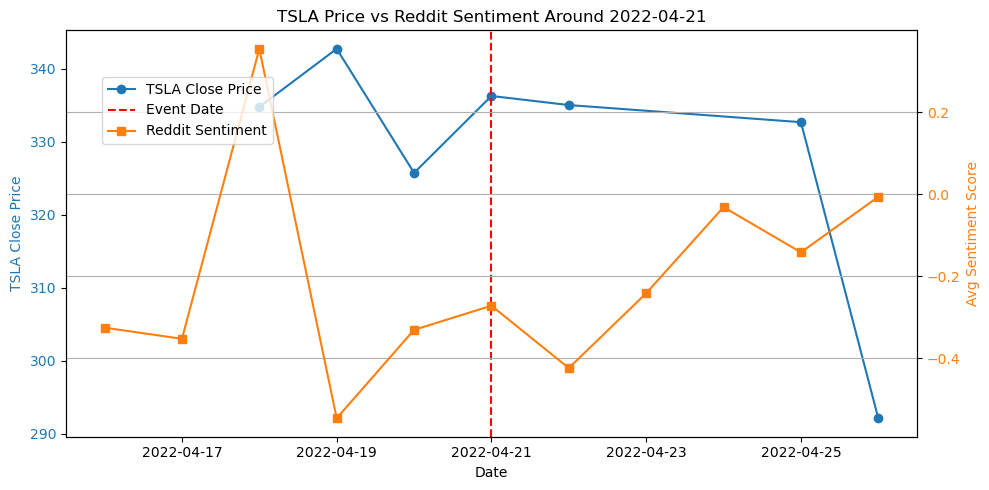

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

event_date = pd.to_datetime("2022-04-21")  # Change this per event
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

reddit_df = pd.read_csv("reddit_comments_with_sentiment.csv")
reddit_df['Timestamp'] = pd.to_datetime(reddit_df['Timestamp'])
reddit_df['Date'] = reddit_df['Timestamp'].dt.date

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
d_2022_03_16 = d[
    (d['Year'] == 2022) &
    (d['Month'] == 3) &
    (d['Day'] == 16)]

texts_2022_03_16 = d_2022_03_16['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2022-03-16: {len(texts_2022_03_16)}")

model_2022_03_16 = Top2Vec(
    documents=texts_2022_03_16,
    speed="deep-learn",    # accurate
    workers=4,
    embedding_model="all-MiniLM-L6-v2"  # light and fast)

topic_words_2022_03_16, _, topic_nums_2022_03_16 = model_2022_03_16.get_topics()

for i, words in enumerate(topic_words_2022_03_16):
    print(f"Topic {i}: {words[:10]}")

2025-04-15 18:30:07,375 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-15 18:30:07,395 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2022-03-16: 180


2025-04-15 18:30:08,710 - top2vec - INFO - Creating joint document/word embedding
2025-04-15 18:30:09,498 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-15 18:30:11,532 - top2vec - INFO - Finding dense areas of documents
2025-04-15 18:30:11,538 - top2vec - INFO - Finding topics


Topic 0: ['lockheed' 'congress' 'plummeting' 'fewer' 'martin' 'collapse' 'nearly'
 'th' 'market' 'close']
Topic 1: ['oil' 'bear' 'market' 'collapse' 'plummeting' 'settling' 'highs'
 'suffers' 'march' 'close']
Topic 2: ['market' 'march' 'wednesday' 'close' 'year' 'highs' 'lockheed' 'in' 'at'
 'th']


[*********************100%***********************]  1 of 1 completed


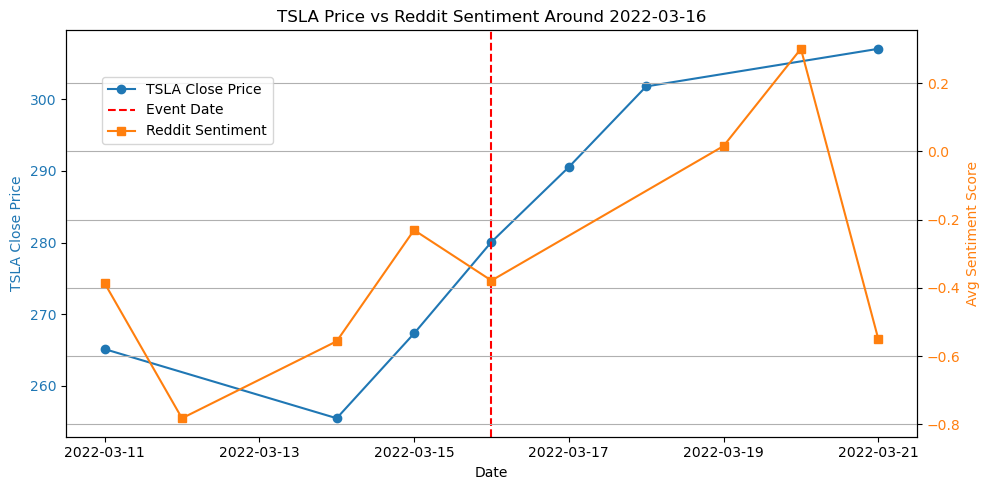

In [90]:
event_date = pd.to_datetime("2022-03-16")  # Change this per event
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')
ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2023 

In [343]:
#2023-01-03
d_2023_01_03 = d[
    (d['Year'] == 2023) &
    (d['Month'] == 1) &
    (d['Day'] == 3)]

texts_2023_01_03 = d_2023_01_03['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2023-01-03: {len(texts_2023_01_03)}")
model_2023_01_03 = Top2Vec(
    documents=texts_2023_01_03,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2023_01_03, _, topic_nums_2023_01_03 = model_2023_01_03.get_topics()
for i, words in enumerate(topic_words_2023_01_03):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:01:59,287 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:01:59,300 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2023-01-03: 85


2025-04-14 02:02:01,246 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:02:01,772 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:02:01,831 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:02:01,833 - top2vec - INFO - Finding topics


Topic 0: ['jpmorgan' 'epsteins' 'island' 'the' 'and' 'to' 'of']
Topic 1: ['of' 'jpmorgan' 'and' 'to' 'the' 'epsteins' 'island']


[*********************100%***********************]  1 of 1 completed


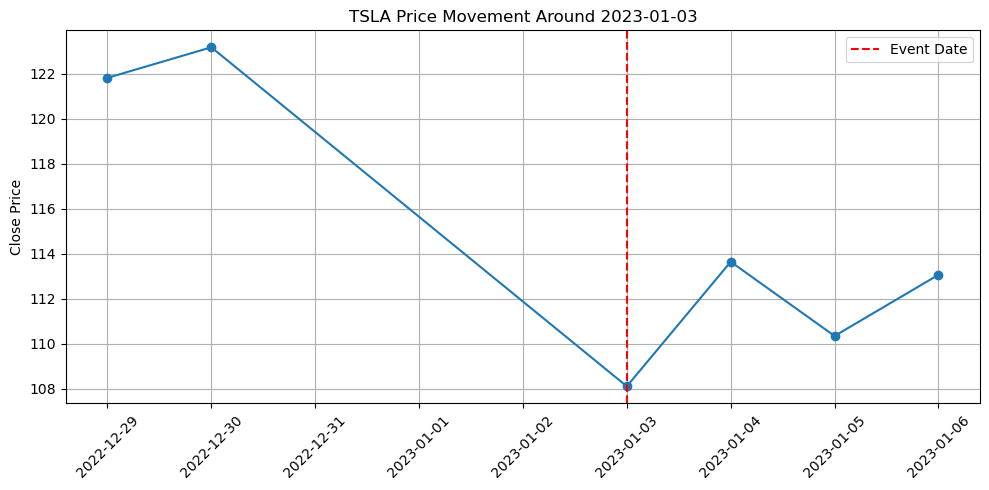

In [48]:
event_date = pd.to_datetime("2023-01-03")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


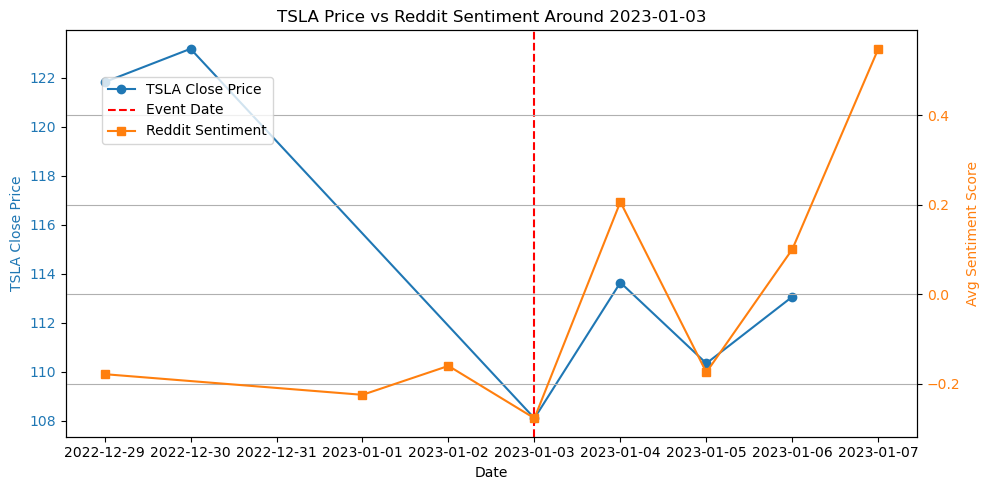

In [104]:
event_date = pd.to_datetime("2023-01-03")
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [345]:
d_2023_04_20 = d[
    (d['Year'] == 2023) &
    (d['Month'] == 4) &
    (d['Day'] == 20)
]

texts_2023_04_20 = d_2023_04_20['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2023-04-20: {len(texts_2023_04_20)}")

model_2023_04_20 = Top2Vec(
    documents=texts_2023_04_20,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2" )

topic_words_2023_04_20, _, topic_nums_2023_04_20 = model_2023_04_20.get_topics()
for i, words in enumerate(topic_words_2023_04_20):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:02:19,330 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:02:19,343 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2023-04-20: 82


2025-04-14 02:02:20,427 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:02:20,648 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:02:20,695 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:02:20,697 - top2vec - INFO - Finding topics


Topic 0: ['seagate' 'huawei' 'blacklisted' 'penalty' 'billion' 'million' 'firm'
 'hit' 'relationship' 'the']
Topic 1: ['hit' 'firm' 'billion' 'million' 'blacklisted' 'seagate' 'for' 'the'
 'continuing' 'with']


[*********************100%***********************]  1 of 1 completed


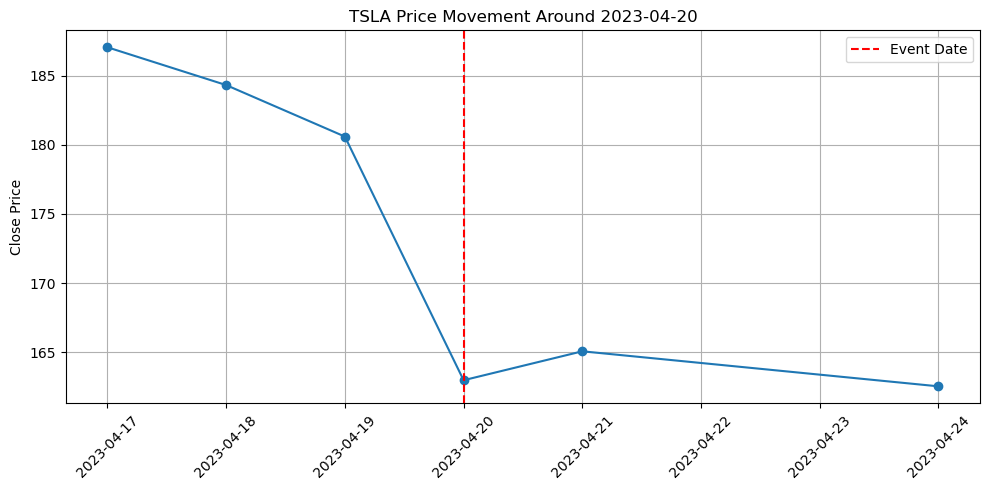

In [50]:
event_date = pd.to_datetime("2023-04-20")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


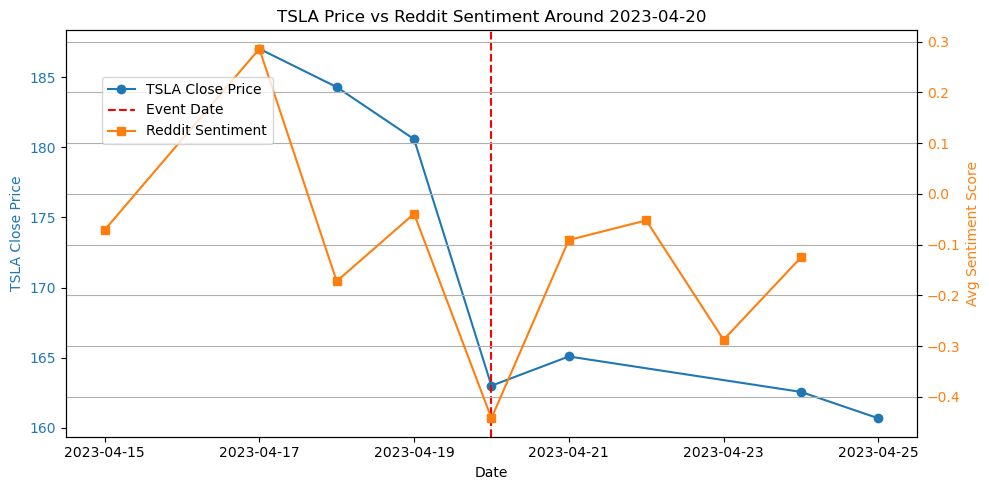

In [102]:
event_date = pd.to_datetime("2023-04-20")
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [361]:
d_2023_09_13 = d[
    (d['Year'] == 2023) &
    (d['Month'] == 9) &
    (d['Day'] == 13)
]

texts_2023_09_13 = d_2023_09_13['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2023-09-13: {len(texts_2023_09_13)}")

model_2023_09_13 = Top2Vec(
    documents=texts_2023_09_13,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2023_09_13, _, topic_nums_2023_09_13 = model_2023_09_13.get_topics()
for i, words in enumerate(topic_words_2023_09_13):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:05:56,533 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:05:56,554 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2023-09-13: 158


2025-04-14 02:05:57,539 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:05:57,861 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:05:57,929 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:05:57,931 - top2vec - INFO - Finding topics


Topic 0: ['supervillain' 'superhero' 'musk' 'elon' 'ceo' 'he' 'from' 'his' 'how'
 'ever']
Topic 1: ['ceo' 'hardest' 'musk' 'working' 'he' 'supervillain' 'his' 'and' 'that'
 'is']


[*********************100%***********************]  1 of 1 completed


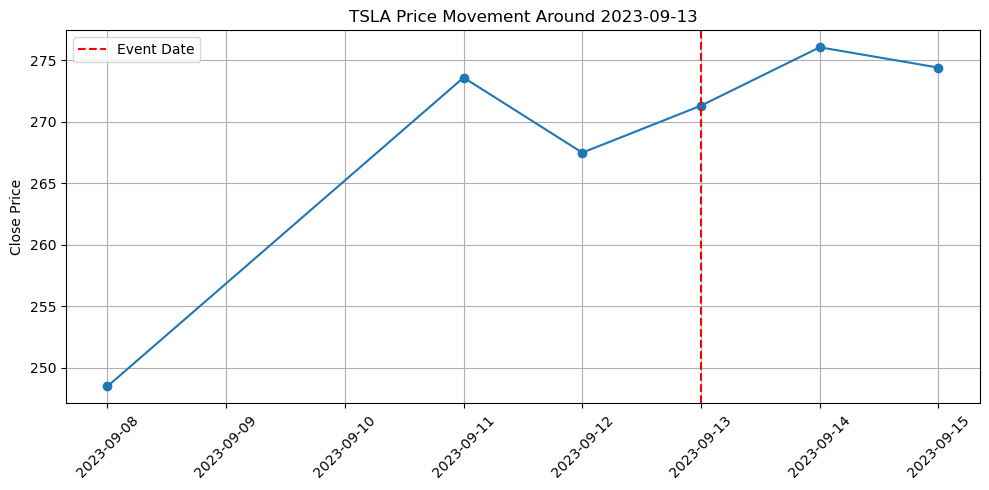

In [52]:
event_date = pd.to_datetime("2023-09-13")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


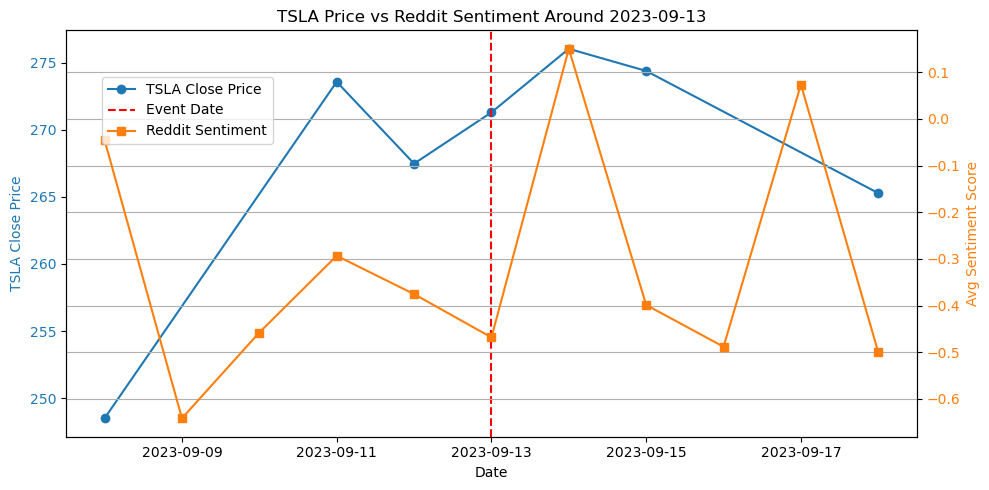

In [100]:
event_date = pd.to_datetime("2023-09-13")  # Change this per event
days_before = 5
days_after = 5


tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2024

In [365]:
d_2024_12_11 = d[
    (d['Year'] == 2024) &
    (d['Month'] == 12) &
    (d['Day'] == 11)]

texts_2024_12_11 = d_2024_12_11['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2024-12-11: {len(texts_2024_12_11)}")

model_2024_12_11 = Top2Vec(
    documents=texts_2024_12_11,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2024_12_11, _, topic_nums_2024_12_11 = model_2024_12_11.get_topics()

for i, words in enumerate(topic_words_2024_12_11):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:07:20,797 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:07:20,818 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2024-12-11: 290


2025-04-14 02:07:22,322 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:07:23,490 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:07:23,616 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:07:23,621 - top2vec - INFO - Finding topics


Topic 0: ['nintendo' 'happened' 'wtf' 'they' 'it' 'in' 'and' 'of' 'to' 'at']
Topic 1: ['in' 'it' 'wtf' 'at' 'happened' 'of' 'to' 'is' 'the' 'nintendo']
Topic 2: ['nintendo' 'happened' 'wtf' 'they' 'it' 'and' 'of' 'in' 'the' 'to']
Topic 3: ['nintendo' 'happened' 'they' 'wtf' 'it' 'of' 'and' 'in' 'the' 'to']
Topic 4: ['at' 'they' 'to' 'and' 'in' 'wtf' 'it' 'is' 'the' 'nintendo']


[*********************100%***********************]  1 of 1 completed


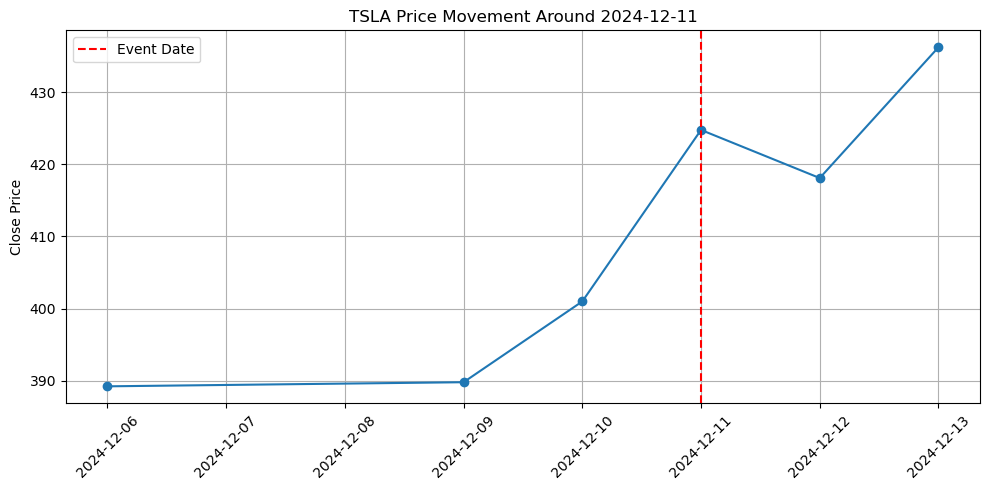

In [54]:
event_date = pd.to_datetime("2024-12-11")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


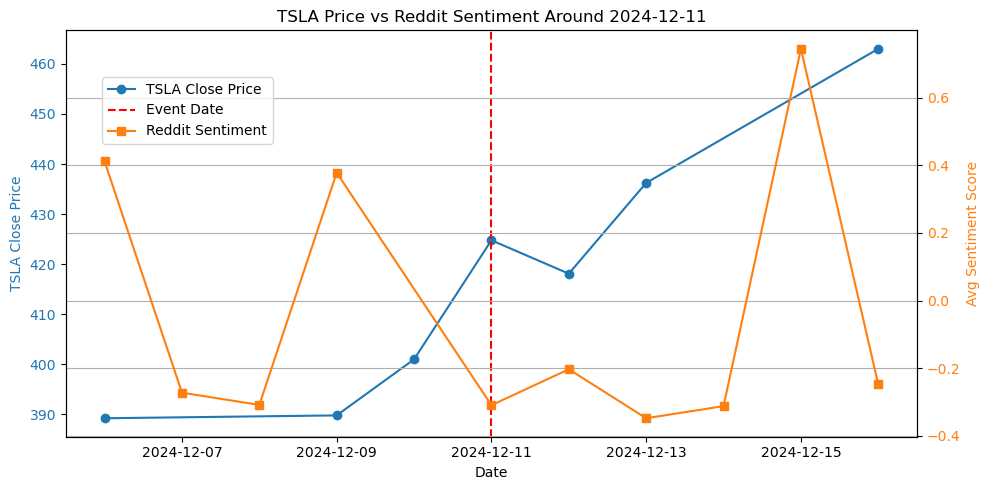

In [98]:
event_date = pd.to_datetime("2024-12-11")  # Change this per event
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')
ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [367]:
d_2024_06_07 = d[
    (d['Year'] == 2024) &
    (d['Month'] == 6) &
    (d['Day'] == 7)]

texts_2024_06_07 = d_2024_06_07['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2024-06-07: {len(texts_2024_06_07)}")

model_2024_06_07 = Top2Vec(
    documents=texts_2024_06_07,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2024_06_07, _, topic_nums_2024_06_07 = model_2024_06_07.get_topics()

for i, words in enumerate(topic_words_2024_06_07):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:09:33,542 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:09:33,571 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2024-06-07: 364


2025-04-14 02:09:34,977 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:09:35,992 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:09:36,151 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:09:36,156 - top2vec - INFO - Finding topics


Topic 0: ['gamestop' 'trader' 'retailer' 'roaring' 'tumbles' 'kitty' 'what'
 'explains' 'livestream' 'ads']
Topic 1: ['tesla' 'teslas' 'musk' 'ads' 'pay' 'billion' 'elon' 'spending' 'money'
 'push']
Topic 2: ['musk' 'tesla' 'teslas' 'pay' 'elon' 'spending' 'money' 'happen' 'chair'
 'see']
Topic 3: ['teslas' 'tesla' 'space' 'unsold' 'billion' 'musk' 'see' 'many' 'they'
 'them']
Topic 4: ['tesla' 'musk' 'teslas' 'billion' 'pay' 'spending' 'money' 'see' 'elon'
 'says']


[*********************100%***********************]  1 of 1 completed


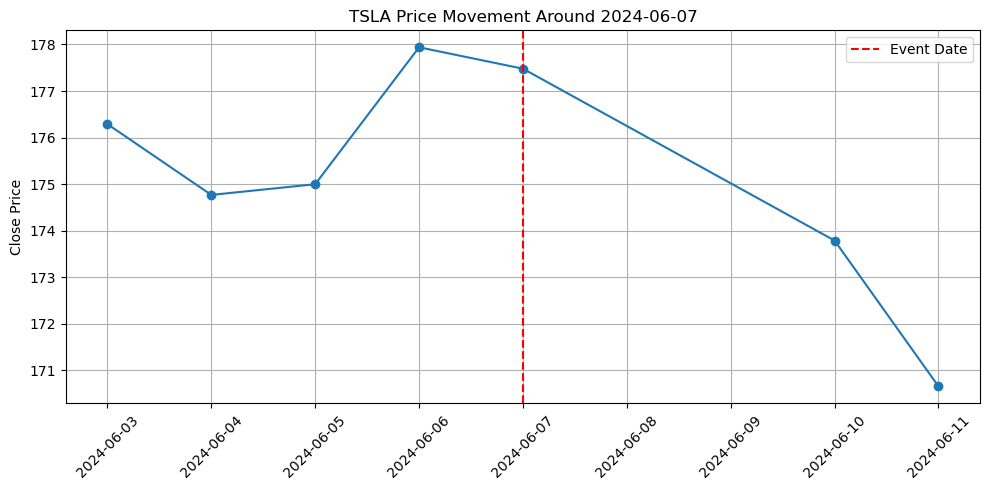

In [56]:
event_date = pd.to_datetime("2024-06-07")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


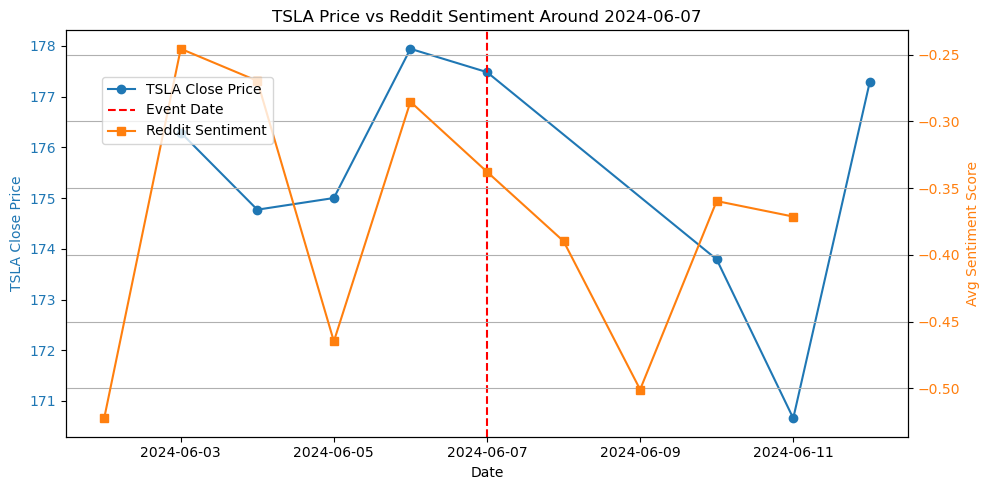

In [106]:
event_date = pd.to_datetime("2024-06-07")
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')
ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2025

In [371]:
d_2025_02_14 = d[
    (d['Year'] == 2025) &
    (d['Month'] == 2) &
    (d['Day'] == 14)]

texts_2025_02_14 = d_2025_02_14['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2025-02-14: {len(texts_2025_02_14)}")

model_2025_02_14 = Top2Vec(
    documents=texts_2025_02_14,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2025_02_14, _, topic_nums_2025_02_14 = model_2025_02_14.get_topics()

for i, words in enumerate(topic_words_2025_02_14):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:11:01,669 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:11:01,711 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2025-02-14: 631


2025-04-14 02:11:03,244 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:11:04,742 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:11:05,051 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:11:05,057 - top2vec - INFO - Finding topics


Topic 0: ['paywall' 'rddt' 'content' 'lock' 'ceo' 'company' 'reddit' 'it' 'not'
 'but']
Topic 1: ['tesla' 'musk' 'toxicity' 'disaster' 'elon' 'ceo' 'spell' 'or' 'this'
 'will']
Topic 2: ['berkshire' 'company' 'ceo' 'spy' 'exited' 'hathaway' 'voo' 'tesla' 'is'
 'has']
Topic 3: ['tesla' 'musk' 'ceo' 'elon' 'company' 'will' 'he' 'reddit' 'disaster'
 'at']
Topic 4: ['tesla' 'musk' 'ceo' 'elon' 'company' 'disaster' 'what' 'or' 'the' 'that']


[*********************100%***********************]  1 of 1 completed


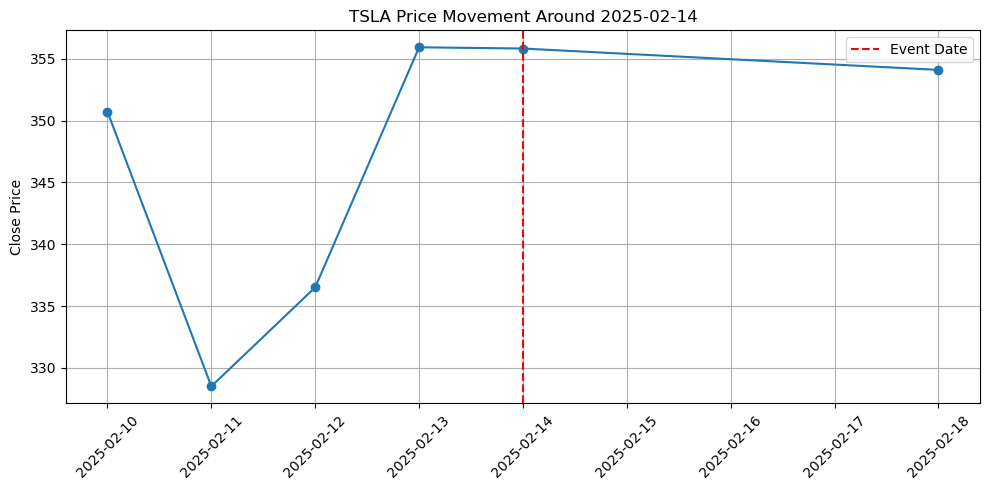

In [58]:
event_date = pd.to_datetime("2025-02-14")
ticker = "TSLA"

# Download TSLA data
tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


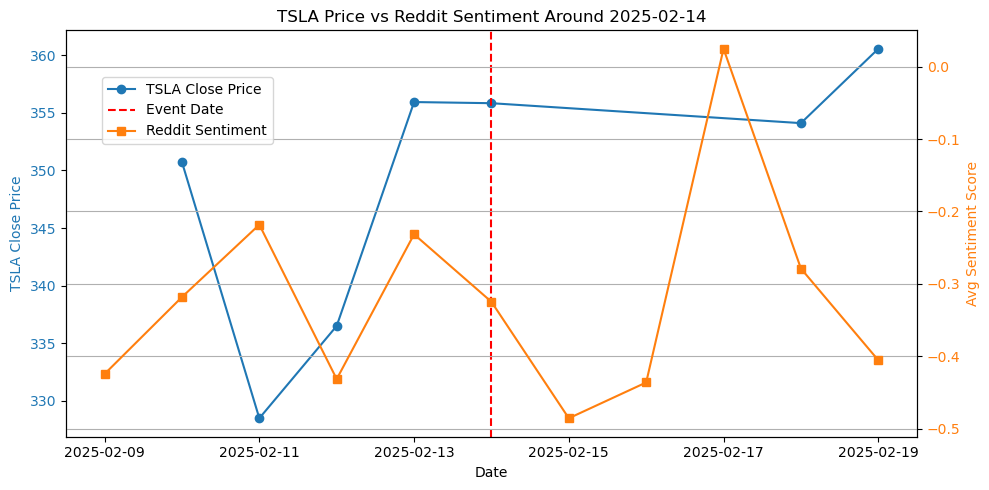

In [108]:
event_date = pd.to_datetime("2025-02-14")  # Change this per event
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [373]:
d_2025_03_05 = d[
    (d['Year'] == 2025) &
    (d['Month'] == 3) &
    (d['Day'] == 5)]

texts_2025_03_05 = d_2025_03_05['Combined_Text'].dropna().tolist()
print(f"Number of posts on 2025-03-05: {len(texts_2025_03_05)}")

model_2025_03_05 = Top2Vec(
    documents=texts_2025_03_05,
    speed="deep-learn",
    workers=4,
    embedding_model="all-MiniLM-L6-v2")

topic_words_2025_03_05, _, topic_nums_2025_03_05 = model_2025_03_05.get_topics()

for i, words in enumerate(topic_words_2025_03_05):
    print(f"Topic {i}: {words[:10]}")

2025-04-14 02:12:27,027 - top2vec - INFO - Pre-processing documents for training
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-04-14 02:12:27,074 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model


Number of posts on 2025-03-05: 696


2025-04-14 02:12:28,423 - top2vec - INFO - Creating joint document/word embedding
2025-04-14 02:12:29,942 - top2vec - INFO - Creating lower dimension embedding of documents
2025-04-14 02:12:30,282 - top2vec - INFO - Finding dense areas of documents
2025-04-14 02:12:30,288 - top2vec - INFO - Finding topics


Topic 0: ['subsidy' 'tariffs' 'chips' 'trump' 'act' 'billion' 'tesla' 'calls'
 'automakers' 'end']
Topic 1: ['tesla' 'elon' 'stock' 'low' 'automakers' 'trump' 'will' 'tariffs'
 'billion' 'musk']
Topic 2: ['tariffs' 'automakers' 'delays' 'tesla' 'subsidy' 'trump' 'stock' 'sales'
 'company' 'china']
Topic 3: ['tesla' 'stock' 'automakers' 'tariffs' 'subsidy' 'sales' 'billion'
 'company' 'more' 'musk']
Topic 4: ['tesla' 'china' 'stock' 'tariffs' 'sales' 'automakers' 'drop' 'company'
 'subsidy' 'what']
Topic 5: ['tesla' 'automakers' 'germany' 'tsla' 'tariffs' 'sales' 'company'
 'subsidy' 'stock' 'china']
Topic 6: ['tesla' 'musk' 'automakers' 'germany' 'sales' 'tariffs' 'subsidy' 'stock'
 'billion' 'company']


[*********************100%***********************]  1 of 1 completed


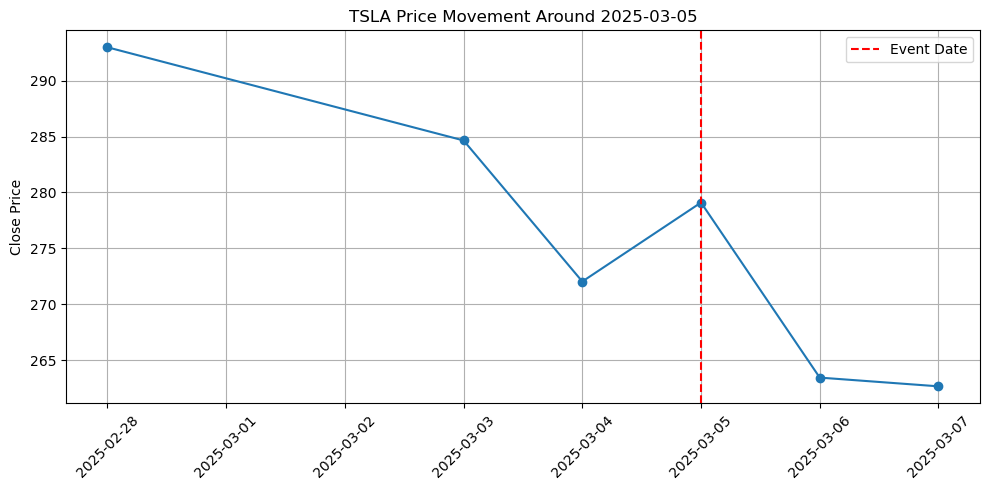

In [60]:
event_date = pd.to_datetime("2025-03-05")
ticker = "TSLA"

tsla = yf.download(ticker, start=event_date - timedelta(days=5), end=event_date + timedelta(days=5))

plt.figure(figsize=(10, 5))
plt.plot(tsla.index, tsla["Close"], marker='o', linestyle='-')
plt.axvline(event_date, color='red', linestyle='--', label="Event Date")
plt.title(f"{ticker} Price Movement Around {event_date.date()}")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


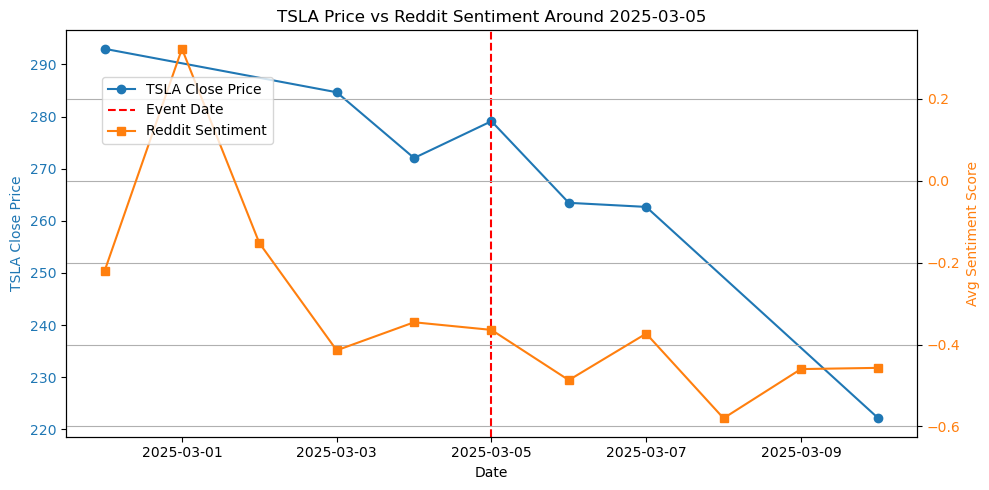

In [110]:
event_date = pd.to_datetime("2025-03-05")  # Change this per event
days_before = 5
days_after = 5

tsla = yf.download("TSLA", start=event_date - pd.Timedelta(days=10), end=event_date + pd.Timedelta(days=10))
tsla.reset_index(inplace=True)

daily_sentiment = reddit_df.groupby('Date')['sentiment_score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

start_date = event_date - pd.Timedelta(days=days_before)
end_date = event_date + pd.Timedelta(days=days_after)

price_window = tsla[(tsla['Date'] >= start_date) & (tsla['Date'] <= end_date)]
sentiment_window = daily_sentiment[(daily_sentiment['Date'] >= start_date) & (daily_sentiment['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(price_window['Date'], price_window['Close'], marker='o', label='TSLA Close Price', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('TSLA Close Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.axvline(event_date, color='red', linestyle='--', label='Event Date')

ax2 = ax1.twinx()
ax2.plot(sentiment_window['Date'], sentiment_window['sentiment_score'], marker='s', label='Reddit Sentiment', color='tab:orange')
ax2.set_ylabel('Avg Sentiment Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"TSLA Price vs Reddit Sentiment Around {event_date.date()}")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

 1. ANOVA (Analysis of Variance)
Goal: Test if average sentiment scores significantly differ across different weekdays or hours.

In [2]:
import pandas as pd
from scipy.stats import f_oneway

df = pd.read_csv("reddit_comments_with_sentiment.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Weekday'] = df['Timestamp'].dt.day_name()

weekday_sentiments = [group['sentiment_score'].dropna().values 
                      for name, group in df.groupby('Weekday')]

#ANOVA
f_stat, p_value = f_oneway(*weekday_sentiments)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4e}")

F-statistic: 61.2030, P-value: 3.6315e-76


In [6]:
from scipy.stats import ttest_ind

split_date = pd.to_datetime("2023-08-07")
before = df[df['Timestamp'] < split_date]['sentiment_score'].dropna()
after = df[df['Timestamp'] >= split_date]['sentiment_score'].dropna()

t_stat, p_value = ttest_ind(before, after, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4e}")

T-statistic: 60.4949, P-value: 0.0000e+00


In [8]:
from scipy.stats import kruskal

weekday_sentiments = [group['sentiment_score'].dropna().values 
                      for name, group in df.groupby('Weekday')]

# Perform Kruskal-Wallis test
h_stat, p_value = kruskal(*weekday_sentiments)
print(f"H-statistic: {h_stat:.4f}, P-value: {p_value:.4e}")

H-statistic: 341.7170, P-value: 9.2559e-71


In [28]:
!pip install yfinance

In [30]:
import yfinance as yf
import pandas as pd

# Download Tesla data
tsla = yf.download('TSLA', start='2022-01-01', end='2025-04-01')

# Reset index
tsla.reset_index(inplace=True)

# Flatten MultiIndex columns if needed
if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = [col[0] if isinstance(col, tuple) else col for col in tsla.columns]

# Now calculate % change for next day
tsla['Pct_Change'] = tsla['Close'].pct_change().shift(-1)

# Keep only relevant columns
tsla = tsla[['Date', 'Close', 'Pct_Change']]

[*********************100%***********************]  1 of 1 completed


In [32]:
# Convert timestamp to datetime just in case
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Aggregate average sentiment score per day
daily_sentiment = df.groupby(df['Timestamp'].dt.date)['sentiment_score'].mean().reset_index()
daily_sentiment.columns = ['Date', 'Avg_Sentiment']
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

In [34]:
merged_df = pd.merge(daily_sentiment, tsla, on='Date', how='inner')
merged_df = merged_df.dropna(subset=['Pct_Change'])

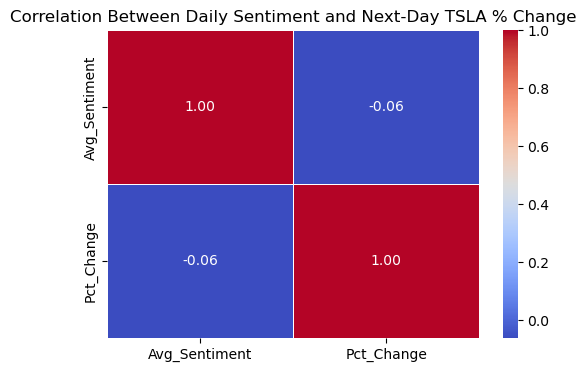

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix = merged_df[['Avg_Sentiment', 'Pct_Change']].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Between Daily Sentiment and Next-Day TSLA % Change")
plt.show()

To evaluate the potential predictive relationship between Reddit sentiment and subsequent stock price movement, we computed the Pearson correlation between daily sentiment scores and next-day TSLA price changes. The result (r = -0.06) indicates no meaningful linear association, suggesting that daily sentiment on Reddit, in isolation, is not a strong predictor of immediate stock performance.

Our statistical correlation analysis between Reddit sentiment and next-day TSLA stock price movement revealed negligible association (r = -0.06). This suggests that discussions on platforms like r/wallstreetbets may be more emotionally reactive to price changes, rather than predictive. In other words, sentiment spikes appear to mirror market movement rather than precede it, highlighting a tendency for retail discussions to follow news and volatility rather than anticipate it.

In [38]:
from statsmodels.tsa.stattools import grangercausalitytests

# Create lagged sentiment
merged_df['Lagged_Sentiment'] = merged_df['Avg_Sentiment'].shift(1)

# Drop NaNs
granger_data = merged_df[['Pct_Change', 'Lagged_Sentiment']].dropna()

# Granger test (does Lagged_Sentiment predict Pct_Change?)
grangercausalitytests(granger_data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0837  , p=0.7724  , df_denom=716, df_num=1
ssr based chi2 test:   chi2=0.0841  , p=0.7719  , df=1
likelihood ratio test: chi2=0.0841  , p=0.7719  , df=1
parameter F test:         F=0.0837  , p=0.7724  , df_denom=716, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0550  , p=0.3488  , df_denom=713, df_num=2
ssr based chi2 test:   chi2=2.1247  , p=0.3456  , df=2
likelihood ratio test: chi2=2.1216  , p=0.3462  , df=2
parameter F test:         F=1.0550  , p=0.3488  , df_denom=713, df_num=2


{1: ({'ssr_ftest': (0.08371954594025958, 0.7724024391947721, 716.0, 1),
   'ssr_chi2test': (0.08407032616067966, 0.7718553816075627, 1),
   'lrtest': (0.08406541150998237, 0.7718618654521625, 1),
   'params_ftest': (0.0837195459405724, 0.7724024391944568, 716.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.0549543905910168, 0.3487511831791341, 713.0, 2),
   'ssr_chi2test': (2.124704775439972, 0.3456417697812045, 2),
   'lrtest': (2.1215672516545965, 0.34618442495524715, 2),
   'params_ftest': (1.054954390590931, 0.34875118317916254, 713.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

              precision    recall  f1-score   support

           0       0.51      0.64      0.57       108
           1       0.53      0.40      0.46       109

    accuracy                           0.52       217
   macro avg       0.52      0.52      0.51       217
weighted avg       0.52      0.52      0.51       217



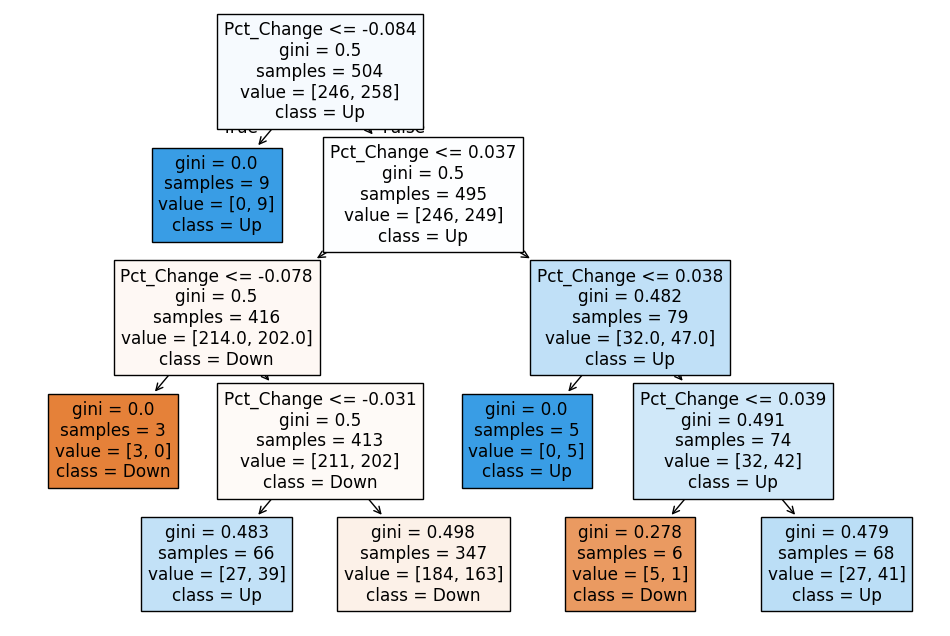

In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Create binary target — tomorrow up/down
merged_df['Target'] = (merged_df['Pct_Change'].shift(-1) > 0).astype(int)

# Step 2: Features
features = ['Avg_Sentiment', 'Pct_Change']  # Add more if available
X = merged_df[features]
y = merged_df['Target']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Fit tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

# Step 5: Evaluate
y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

# Optional: Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=features, class_names=["Down", "Up"], filled=True)
plt.show()

1. The average Reddit sentiment was not strong enough to help decision-making for price movement.